<a href="https://colab.research.google.com/github/igttsPro/DEV_ML_AI/blob/main/Multilcriteria_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import Analytic and Visualization Lib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

!pip install pygsheets

# !pip install openpyxl --upgrade
!pip install --upgrade pandas openpyxl

# Install the necessary library if you haven't already
!pip install pyreadstat

# Import the library
import pyreadstat


from openpyxl import load_workbook

# Import Google Drive
from google.colab import drive

# Mount Drive
drive.mount('/content/drive')

# specify file path for input
file_path = '/content/drive/My Drive/MultilevelDataAnalysis/'

  Using cached pyreadstat-1.3.3-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (1.2 kB)
Using cached pyreadstat-1.3.3-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (3.1 MB)
Mounted at /content/drive


In [ ]:
!pip install bambi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.6/109.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.9/218.9 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.4/259.4 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.6/164.6 kB 5.0 MB/s eta 0:00:00


READ DATA

In [ ]:
# Read data to workspace
df = pd.read_csv(file_path + 'Extracted _Dataset_Multilevel _Analysis.csv')


DATA CLEANING AND MANIPULATION

# Remove hidden xters or extra spaces
df.columns = df.columns.str.strip()


# Renaming columns for clearity
df = df.rename(columns={'Q601. Have you submitted a suspected ADR/AEFI report before?': 'Reported',
                        'Q606. What reasons are responsible for not reporting an ADR/AEFI from this facility to the National Pharmacovigilance Center in the last one year?': 'Q606',
                        'Q207. Designation of Respondent': 'Designation',
                        'Q301. Type of Health Facility of practice': 'FacilityType',
                        'State': 'State',
                        'Q203. Age of Respondent at last Birthday': 'Age',
                        'Q204. Gender of respondent:': 'Gender',
                        'Q206. Years of experience at present place of practice:': 'YearsExperience'})

# Lock the data for model stability
df_model = df[
    ["Reported", "Designation", "FacilityType",
     "Age", "Gender", "YearsExperience", "State"]
].dropna()


# Enforce categorical variables
for col in ["Designation", "FacilityType", "Gender", "State"]:
    df_model[col] = df_model[col].astype("category")


# Column converstions:
## Convert 'Age' to numeric, coercing errors to NaN
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

# Filter out implausible ages (e.g., < 20 or > 100 years)
df = df[(df['Age'] >= 20) & (df['Age'] <= 100)]

# Binary outcome: Has submitted ADR/AEFI report (Yes=1, No=0)
# Convert 'Reported' to numeric, coercing errors to NaN first, then map
df['Reported'] = df['Reported'].map({"Yes": 1, "No": 0})

cols = ["Reported", "Designation", "FacilityType", "Age", "Gender", "YearsExperience", "State"]

print('\n', df_model[cols].info())   # Quick overview
print('\n', df_model[cols].isnull().sum())
print('\n', df_model[cols].nunique())
print('\n', df_model["Reported"].value_counts(dropna=False), '\n')  # Quick sanity check for the concerned column







# Explicitly drop rows with NaNs in relevant columns before further processing
# This ensures a clean dataset for the mixed model

In [ ]:
# Clean column names
df.columns = df.columns.str.strip()

# Rename columns
df = df.rename(columns={
    'Q601. Have you submitted a suspected ADR/AEFI report before?': 'Reported',
    'Q606. What reasons are responsible for not reporting an ADR/AEFI from this facility to the National Pharmacovigilance Center in the last one year?': 'Q606',
    'Q207. Designation of Respondent': 'Designation',
    'Q301. Type of Health Facility of practice': 'FacilityType',
    'State': 'State',
    'Q203. Age of Respondent at last Birthday': 'Age',
    'Q204. Gender of respondent:': 'Gender',
    'Q206. Years of experience at present place of practice:': 'YearsExperience'
})

# Convert Age safely
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")

# Filter outliers from age column
df = df[(df["Age"] >= 20) & (df["Age"] <= 100)]

# Safe binary mapping (REPLACE, not MAP)
df["Reported"] = df["Reported"].replace({"Yes": 1, "No": 0})


# # Standardize Designation column
designation_mapping = {
    'Community Health Extension Workers (CHEWs)': 'CHEW',
    'CHEWs': 'CHEW',
    'Community Health Extension Worker': 'CHEW',
    'Community Health Extension Workers': 'CHEW',
    'M&E officer': 'M&E Officer',
    'FACILITY M&E': 'M&E Officer',
    'Facility M&E': 'M&E Officer',
    'Head of M & E': 'M&E Officer',
    'Chief Pharmacy Technician ': 'Chief Pharmacy Technician',
    'Medical Lab Scientist': 'Lab. Scientist',
    'Medical laboratory scientist': 'Lab. Scientist',
    'Medical laboratory Scientist': 'Lab. Scientist',
    'Medical lab scientist': 'Lab. Scientist',
    'Nurse/Midwife': 'Nurse',
    'Mid wife': 'Nurse'
}
df['Designation'] = df['Designation'].astype(str).replace(designation_mapping)


# Barrier coding (you’ll need to expand for all Q606 reasons)
df["Barrier_awareness"] = df["Q606"].str.contains("awareness", case=False).astype(int)
df["Barrier_ADR/AEFI/AEFI_info"] = df["Q606"].str.contains("information", case=False).astype(int)
df["Barrier_hospitalMgt"] = df["Q606"].str.contains("Hospital management", case=False).astype(int)
df["Barrier_training"] = df["Q606"].str.contains("Training", case=False).astype(int)
df["Barrier_complex"] = df["Q606"].str.contains("complex", case=False).astype(int)
df["Barrier_fear"] = df["Q606"].str.contains("fear", case=False).astype(int)
df["Barrier_feedback"] = df["Q606"].str.contains("feedback", case=False).astype(int)
df["Barrier_distance"] = df["Q606"].str.contains("too far", case=False).astype(int)
df["Barrier_time"] = df["Q606"].str.contains("time", case=False).astype(int)
df["Barrier_not_sure"] = df["Q606"].str.contains("not sure", case=False).astype(int)
df["Barrier_not_important"] = df["Q606"].str.contains("not serious", case=False).astype(int)
df["Barrier_N/A"] = df["Q606"].str.contains("Not Applicable", case=False).astype(int)
df["Barrier_other"] = df["Q606"].str.contains("please specify", case=False).astype(int)



# Lock model data AFTER cleaning
cols = ["Reported", "Designation", "FacilityType",
        "Age", "Gender", "YearsExperience", "State"]

df_model = df[cols].dropna().copy()

# Enforce integer/binary on Reported column
df_model["Reported"] = df_model["Reported"].astype(int)

# Enforce categorical variables
for col in ["Designation", "FacilityType", "Gender", "State"]:
    df_model[col] = df_model[col].astype("category")



In [ ]:
# Diagnostics Data Inspection
print(df_model.info())
print("\nIsNull Valuess:\n", df_model.isnull().sum())
print("\nUnique values:\n", df_model.nunique())
print("\nReported distribution:\n", df_model["Reported"].value_counts(dropna=False), '\n')
print(f"Reported column datatype: {df_model["Reported"].dtype}", '\n')


## Display rows with potentially incorrect Designation or duplicate roles (e.g., those appearing only once)
designation_counts = df['Designation'].value_counts()
single_occurrence_designations = designation_counts[designation_counts == 1].index
incorrect_roles = df_model[df_model['Designation'].isin(single_occurrence_designations)]
display(incorrect_roles[['Designation', 'FacilityType', 'State']])


<class 'pandas.DataFrame'>
Index: 1003 entries, 0 to 1153
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   Reported         1003 non-null   int64   
 1   Designation      1003 non-null   category
 2   FacilityType     1003 non-null   category
 3   Age              1003 non-null   float64 
 4   Gender           1003 non-null   category
 5   YearsExperience  1003 non-null   int64   
 6   State            1003 non-null   category
dtypes: category(4), float64(1), int64(2)
memory usage: 38.3 KB
None

IsNull Valuess:
 Reported           0
Designation        0
FacilityType       0
Age                0
Gender             0
YearsExperience    0
State              0
dtype: int64

Unique values:
 Reported             2
Designation        103
FacilityType         4
Age                 48
Gender               2
YearsExperience     41
State               12
dtype: int64

Reported distribution:
 Reported
0    748
1    2

,Designation,FacilityType,State
10,Health Attendant,"Tertiary Health Facility,",Benue
20,Social Worker,Private Health Facility,Kaduna
26,Pharmacist technician,Private Health Facility,Kaduna
27,Laboratory technician,Private Health Facility,Kaduna
28,Medical Officer,Private Health Facility,Kaduna
...,...,...,...
1095,Administrative officer 2,"Tertiary Health Facility,",Cross River
1098,Health Records officer,"Tertiary Health Facility,",Cross River
1103,Principal Data Processing Officer,"Tertiary Health Facility,",Cross River
1115,Officer in charge PHC/Nutritionist,Primary Healthcare Facility,Bayelsa


In [ ]:
# Model 1

import statsmodels.formula.api as smf

model = smf.mixedlm(
    "Reported ~ Designation + FacilityType + Age + Gender + YearsExperience",
    df_model,
    groups="State"
)

result = model.fit()
print(result.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


                               Mixed Linear Model Regression Results
Model:                            MixedLM               Dependent Variable:               Reported 
No. Observations:                 1003                  Method:                           REML     
No. Groups:                       12                    Scale:                            0.1626   
Min. group size:                  63                    Log-Likelihood:                   -507.9524
Max. group size:                  109                   Converged:                        Yes      
Mean group size:                  83.6                                                             
---------------------------------------------------------------------------------------------------
                                                         Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------------------------------
Intercept                      

In [ ]:
# Model 2

# How Designation, Facility type, and State influence reporting practice
# Using:
# Q01: Have you submitted a suspected ADR/AEFI report before? (Yes/No)
# Q06: What reasons are responsible for not reporting an ADR/AEFI from this facility to the National Pharmacovigilance Center in the last one year?
        #Lack of awareness on how to report?

import statsmodels.formula.api as smf

# Mixed-effects logistic regression
model = smf.mixedlm("Reported ~ Designation + FacilityType + Age + Gender + YearsExperience",
                    df_model,
                    groups=df_model["State"],          # Level 3 random effect
                    re_formula="~FacilityType")  # Level 2 random effect nested in State

result = model.fit()
print(result.summary())

# Save the model summary as a text file
summary_str = result.summary().as_text()
with open("model_summary.txt", "w") as f:
    f.write(summary_str)

# df_model.groupby("State")["FacilityType"].nunique().describe()


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


                                                Mixed Linear Model Regression Results
Model:                                      MixedLM                           Dependent Variable:                           Reported 
No. Observations:                           1003                              Method:                                       REML     
No. Groups:                                 12                                Scale:                                        0.1595   
Min. group size:                            63                                Log-Likelihood:                               -505.4319
Max. group size:                            109                               Converged:                                    Yes      
Mean group size:                            83.6                                                                                     
--------------------------------------------------------------------------------------------------------------

In [ ]:
# Model 3

import statsmodels.api as sm
import statsmodels.formula.api as smf

model = smf.gee(
    "Reported ~ Designation + FacilityType + Age + Gender + YearsExperience",
    groups="State",
    data=df_model,
    family=sm.families.Binomial()
)

result = model.fit()
print(result.summary())

                               GEE Regression Results                              
Dep. Variable:                    Reported   No. Observations:                 1003
Model:                                 GEE   No. clusters:                       12
Method:                        Generalized   Min. cluster size:                  63
                      Estimating Equations   Max. cluster size:                 109
Family:                           Binomial   Mean cluster size:                83.6
Dependence structure:         Independence   Num. iterations:                     2
Date:                     Tue, 10 Feb 2026   Scale:                           1.000
Covariance type:                    robust   Time:                         11:19:21
                                                               coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/generalized_estimating_equations.py:1842: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_robust))


# Model 3  with error
import statsmodels.api as sm
import statsmodels.formula.api as smf

model3_final = smf.gee(
    formula="""
        Reported ~
        DesignationGroup +
        FacilityType +
        Age +
        Gender +
        YearsExperience
    """,
    groups="State",
    data=df_model,
    family=sm.families.Binomial(),
    cov_struct=sm.cov_struct.Independence()
)

result3 = model3_final.fit()
print(result3.summary())


In [ ]:
# Model 4

# Best statistical solution (clean + robust)
# Use a true logistic mixed-effects model.
# If you want to stay in Python and keep random slopes:
import arviz as az
import bambi as bmb

model = bmb.Model(
    "Reported ~ Designation + FacilityType + Age + Gender + YearsExperience + (1 + FacilityType | State)",
    df_model,
    family="bernoulli"
)

result = model.fit()
az.summary(result)

Output()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
1|State[Abia],0.251,0.264,-0.216,0.760,0.007,0.006,1380.0,1485.0,1.00
1|State[Adamawa],0.059,0.280,-0.483,0.596,0.006,0.007,2020.0,1612.0,1.00
1|State[Anambra],-0.190,0.284,-0.804,0.284,0.007,0.006,1508.0,1413.0,1.00
1|State[Bauchi],-0.216,0.271,-0.772,0.256,0.007,0.006,1457.0,1480.0,1.00
1|State[Bayelsa],0.106,0.288,-0.407,0.723,0.007,0.007,1496.0,1329.0,1.00
...,...,...,...,...,...,...,...,...,...
"FacilityType|State_sigma[Secondary Health Facility,]",0.972,0.475,0.003,1.727,0.022,0.018,404.0,250.0,1.01
"FacilityType|State_sigma[Tertiary Health Facility,]",0.287,0.217,0.000,0.662,0.011,0.006,333.0,735.0,1.00
Gender[Male],0.270,0.197,-0.077,0.671,0.004,0.005,2270.0,1269.0,1.00
Intercept,-2.192,0.483,-3.107,-1.297,0.014,0.009,1121.0,1686.0,1.00


In [ ]:
az.summary(result).to_csv("bambi_results.csv")

In [ ]:
# Barrier coding (you’ll need to expand for all Q606 reasons)
df["Barrier_awareness"] = df["Q606"].str.contains("awareness", case=False).astype(int)
df["Barrier_ADR_AEFI_AEFI_info"] = df["Q606"].str.contains("information", case=False).astype(int)
df["Barrier_hospitalMgt"] = df["Q606"].str.contains("Hospital management", case=False).astype(int)
df["Barrier_training"] = df["Q606"].str.contains("Training", case=False).astype(int)
df["Barrier_complex"] = df["Q606"].str.contains("complex", case=False).astype(int)
df["Barrier_fear"] = df["Q606"].str.contains("fear", case=False).astype(int)
df["Barrier_feedback"] = df["Q606"].str.contains("feedback", case=False).astype(int)
df["Barrier_distance"] = df["Q606"].str.contains("too far", case=False).astype(int)
df["Barrier_time"] = df["Q606"].str.contains("time", case=False).astype(int)
df["Barrier_not_sure"] = df["Q606"].str.contains("not sure", case=False).astype(int)
df["Barrier_not_important"] = df["Q606"].str.contains("not serious", case=False).astype(int)
df["Barrier_NA"] = df["Q606"].str.contains("Not Applicable", case=False).astype(int)
df["Barrier_other"] = df["Q606"].str.contains("please specify", case=False).astype(int)


barrier_cols = [
    "Barrier_awareness",
    "Barrier_ADR_AEFI_AEFI_info",
    "Barrier_hospitalMgt",
    "Barrier_training",
    "Barrier_complex",
    "Barrier_fear",
    "Barrier_feedback",
    "Barrier_distance",
    "Barrier_time",
    "Barrier_not_sure",
    "Barrier_not_important",
    "Barrier_NA",
    "Barrier_other"
]

base_cols = ["Reported", "Age", "Gender", "YearsExperience", "State", "FacilityType"]

df_model2 = (
    df[base_cols + barrier_cols]
    .dropna()
    .copy()
)

for col in ["Gender", "State", "FacilityType"]:
    df_model2[col] = df_model2[col].astype("category")


df_model2["Reported"] = (
    df_model2["Reported"]
    .replace({"Yes": 1, "No": 0})
    .astype(int)
)

In [ ]:
# Barriers or Reasons for not sending the Report
# Model 1

import statsmodels.api as sm
import statsmodels.formula.api as smf

model = smf.gee(
    "Reported ~ " + " + ".join(barrier_cols),
    groups="State",
    data=df_model2,
    family=sm.families.Binomial()
)

result = model.fit()
print(result.summary())


                               GEE Regression Results                              
Dep. Variable:                    Reported   No. Observations:                 1003
Model:                                 GEE   No. clusters:                       12
Method:                        Generalized   Min. cluster size:                  63
                      Estimating Equations   Max. cluster size:                 109
Family:                           Binomial   Mean cluster size:                83.6
Dependence structure:         Independence   Num. iterations:                     2
Date:                     Tue, 10 Feb 2026   Scale:                           1.000
Covariance type:                    robust   Time:                         11:21:29
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                      4.8481      0.682      

In [ ]:
# Barriers or Reasons for not sending the Report
# Model 2


model = smf.mixedlm(
    "Reported ~ " + " + ".join(barrier_cols),
    df_model2,
    groups="State",
    re_formula="~FacilityType"
)

result = model.fit()
print(result.summary())


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


                                                Mixed Linear Model Regression Results
Model:                                       MixedLM                           Dependent Variable:                           Reported 
No. Observations:                            1003                              Method:                                       REML     
No. Groups:                                  12                                Scale:                                        0.0733   
Min. group size:                             63                                Log-Likelihood:                               -150.4969
Max. group size:                             109                               Converged:                                    Yes      
Mean group size:                             83.6                                                                                     
--------------------------------------------------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [ ]:
# Random effects by state

# Extract random effects by state
state_effects = result.random_effects

# Convert to DataFrame for easier viewing
state_df = pd.DataFrame(state_effects).T

# Select the 'State' column which represents the random intercept effect for each state
# Then rename this column to 'State_effect'
state_df = state_df[["State"]].copy()
state_df.rename(columns={"State": "State_effect"}, inplace=True)

# The index is already the state names, so reset_index to make 'State' a regular column
state_df.reset_index(inplace=True)
state_df.rename(columns={"index":"State"}, inplace=True)

print(state_df)

          State  State_effect
0          Abia      0.051332
1       Adamawa     -0.043107
2       Anambra     -0.037769
3        Bauchi     -0.028541
4       Bayelsa      0.024668
5         Benue      0.007357
6   Cross River      0.027032
7        Kaduna      0.068961
8      Nasarawa      0.070032
9          Ogun     -0.116963
10          Oyo      0.064398
11       Sokoto      0.003478


In [ ]:
import numpy as np

# Get fixed effect intercept
intercept = result.fe_params["Intercept"]

# Calculate predicted probability for each state (baseline, no barriers)
state_df["Predicted_prob"] = 1 / (1 + np.exp(-(intercept + state_df["State_effect"])))

display(state_df)

,State,State_effect,Predicted_prob
0,Abia,0.051332,0.679639
1,Adamawa,-0.043107,0.658738
2,Anambra,-0.037769,0.659937
3,Bauchi,-0.028541,0.662005
4,Bayelsa,0.024668,0.673806
5,Benue,0.007357,0.669990
6,Cross River,0.027032,0.674325
7,Kaduna,0.068961,0.683465
8,Nasarawa,0.070032,0.683697
9,Ogun,-0.116963,0.641946


/tmp/ipython-input-222411085.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="State", y="Predicted_prob", data=state_df, palette="viridis")


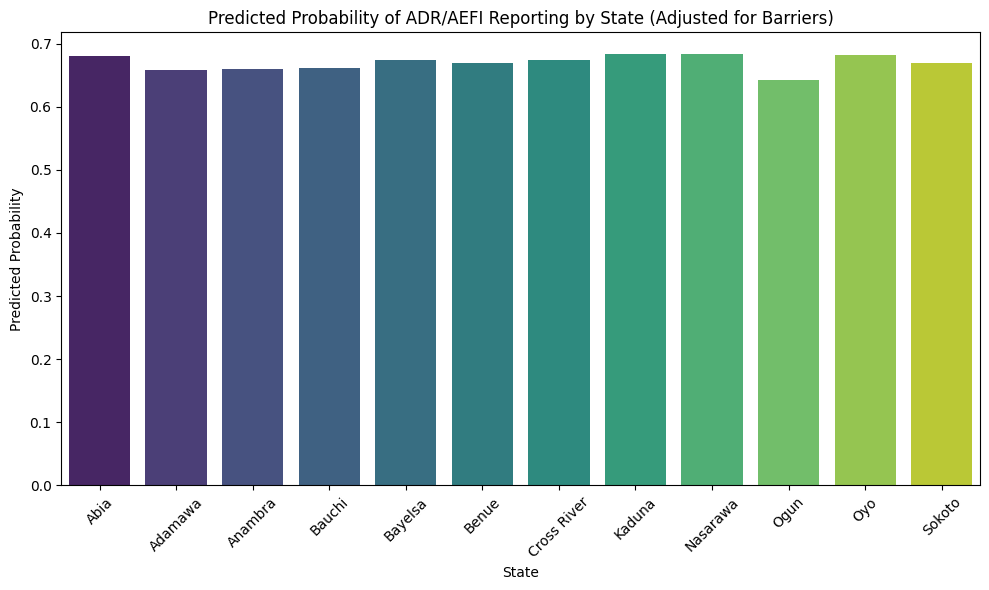

In [ ]:
# Visualize State-Level Probabilities

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(x="State", y="Predicted_prob", data=state_df, palette="viridis")
plt.title("Predicted Probability of ADR/AEFI Reporting by State (Adjusted for Barriers)")
plt.ylabel("Predicted Probability")
plt.xlabel("State")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# Extract Facility Random Effects
# After fitting the mixed-effects model, you can pull out the facility type effects nested within states:
# Extract facility-level random effects

# The `result.random_effects` dictionary contains random effects for each state.
# Each entry is a Series with a 'State' random intercept and random slopes for FacilityType.

# Convert the dictionary of Series to a DataFrame, with states as index and effects as columns
facility_effects_df_wide = pd.DataFrame(result.random_effects).T

# Make the state names an explicit column and rename the 'State' random effect column
facility_effects_df_wide.reset_index(inplace=True)
facility_effects_df_wide.rename(columns={'index': 'State', 'State': 'State_Random_Intercept'}, inplace=True)

# Identify columns that represent FacilityType random slopes
facility_type_slope_cols = [col for col in facility_effects_df_wide.columns if 'FacilityType[' in col]

# Melt the DataFrame to create a long format, showing each FacilityType random slope for each state
facility_df = facility_effects_df_wide.melt(
    id_vars=['State', 'State_Random_Intercept'],
    value_vars=facility_type_slope_cols,
    var_name='Random_Effect_Type',
    value_name='FacilityType_Random_Slope'
)

# Extract a cleaner FacilityType name for better readability
facility_df['FacilityType'] = facility_df['Random_Effect_Type'].str.extract(r'\[T\.(.*?)\]')

# Drop the intermediate random effect type column
facility_df.drop(columns=['Random_Effect_Type'], inplace=True)

# Predicted probability baseline (no barriers)
# This calculation combines the fixed intercept, the state-specific random intercept,
# and the state- and facility-type-specific random slope.
intercept = result.fe_params["Intercept"]
facility_df["Predicted_prob"] = 1 / (1 + np.exp(-(intercept + facility_df["State_Random_Intercept"] + facility_df["FacilityType_Random_Slope"])))



In [ ]:
display(facility_grouped_plotting_df)
display(facility_df)

,FacilityType,Predicted_prob,Lower_CI,Upper_CI
0,Primary Healthcare Facility,0.101074,0.025806,0.312936
1,Private Health Facility,0.057868,0.001383,0.682592
2,"Secondary Health Facility,",0.046392,0.001741,0.510695
3,"Tertiary Health Facility,",0.080352,0.007186,0.496829


,State,State_Random_Intercept,FacilityType_Random_Slope,FacilityType,Predicted_prob
0,Abia,0.051332,-0.050354,Private Health Facility,0.668578
1,Adamawa,-0.043107,0.016892,Private Health Facility,0.662525
2,Anambra,-0.037769,-0.003123,Private Health Facility,0.659236
3,Bauchi,-0.028541,0.017039,Private Health Facility,0.665807
4,Bayelsa,0.024668,0.043889,Private Health Facility,0.683378
5,Benue,0.007357,0.005112,Private Health Facility,0.671119
6,Cross River,0.027032,-0.112838,Private Health Facility,0.649075
7,Kaduna,0.068961,-0.050712,Private Health Facility,0.672394
8,Nasarawa,0.070032,-0.051803,Private Health Facility,0.672389
9,Ogun,-0.116963,0.052009,Private Health Facility,0.653810


/tmp/ipython-input-4051729740.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="FacilityType", y="Predicted_prob", data=facility_grouped_plotting_df, palette="magma")


([0, 1, 2, 3],
 [Text(0, 0, 'Primary Healthcare Facility'),
  Text(1, 0, 'Private Health Facility'),
  Text(2, 0, 'Secondary Health Facility,'),
  Text(3, 0, 'Tertiary Health Facility,')])

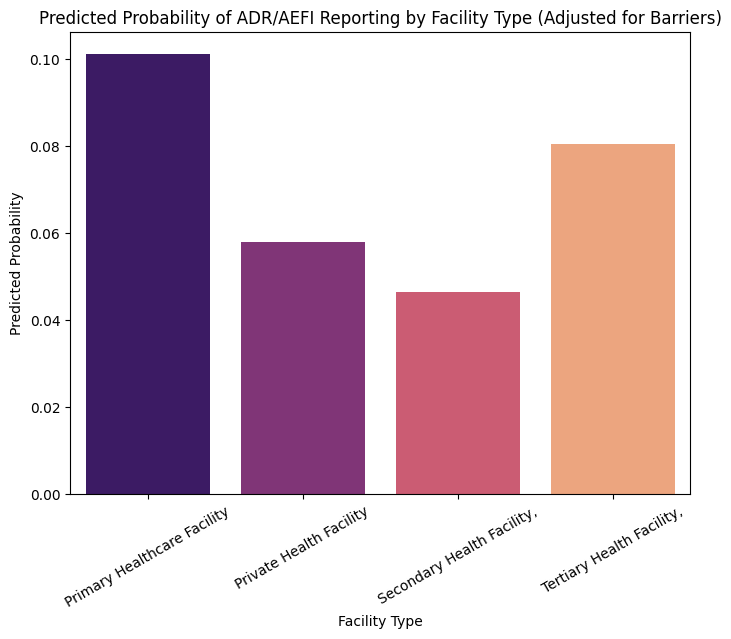

In [ ]:
# Visualize Facility-Level Probabilities

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.barplot(x="FacilityType", y="Predicted_prob", data=facility_grouped_plotting_df, palette="magma")
plt.title("Predicted Probability of ADR/AEFI Reporting by Facility Type (Adjusted for Barriers)")
plt.ylabel("Predicted Probability")
plt.xlabel("Facility Type")
plt.xticks(rotation=30)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# --- State-level random effects ---
state_effects = result.random_effects
state_df_raw = pd.DataFrame(state_effects).T
state_df = state_df_raw[["State"]].copy()
state_df.rename(columns={"State": "State_effect"}, inplace=True)
state_df.reset_index(inplace=True)
state_df.rename(columns={"index":"State"}, inplace=True)

intercept = result.fe_params["Intercept"]
state_df["Predicted_prob"] = 1 / (1 + np.exp(-(intercept + state_df["State_effect"])))

# --- Facility-level random effects ---
facility_effects_df_wide = pd.DataFrame(result.random_effects).T
facility_effects_df_wide.reset_index(inplace=True)
facility_effects_df_wide.rename(columns={'index': 'State', 'State': 'State_Random_Intercept'}, inplace=True)

facility_type_slope_cols = [col for col in facility_effects_df_wide.columns if 'FacilityType[' in col]

facility_df = facility_effects_df_wide.melt(
    id_vars=['State', 'State_Random_Intercept'],
    value_vars=facility_type_slope_cols,
    var_name='Random_Effect_Type',
    value_name='FacilityType_Random_Slope'
)
facility_df['FacilityType'] = facility_df['Random_Effect_Type'].str.extract(r'\[T\.(.*?)\]')
facility_df.drop(columns=['Random_Effect_Type'], inplace=True)

facility_df["Predicted_prob"] = 1 / (1 + np.exp(-(intercept + facility_df["State_Random_Intercept"] + facility_df["FacilityType_Random_Slope"])))

# --- Dashboard-style visualization ---
fig, axes = plt.subplots(1, 2, figsize=(16,6))

# State-level chart
sns.barplot(x="State", y="Predicted_prob", data=state_df, palette="viridis", ax=axes[0], hue="State", legend=False)
axes[0].set_title("Predicted Probability of ADR/AEFI Reporting by State")
axes[0].set_ylabel("Predicted Probability")
axes[0].set_xlabel("State")
axes[0].tick_params(axis='x', rotation=45)

# Facility-level chart
sns.barplot(x="FacilityType", y="Predicted_prob", data=facility_df, palette="magma", ax=axes[1], hue="FacilityType", legend=False)
axes[1].set_title("Predicted Probability of ADR/AEFI Reporting by Facility Type")
axes[1].set_ylabel("Predicted Probability")
axes[1].set_xlabel("Facility Type")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

AttributeError: 'InferenceData' object has no attribute 'random_effects'

### Explanation of Facility Type Analysis in the Report

Under the hood, when analyzing the influence of different **Facility Types** on ADR/AEFI reporting practices, our statistical model (a mixed-effects logistic regression) employs a standard approach known as using a **reference category**. In this analysis, **'Primary Healthcare Facility'** was designated as the **baseline reference group.**

This means:

*   The model's intercept represents the baseline predicted probability of reporting for Primary Healthcare Facilities.
*   The effects observed for 'Private Health Facility', 'Secondary Health Facility', and 'Tertiary Health Facility' indicate how their predicted reporting probabilities differ *relative* to that of Primary Healthcare Facilities, all other factors being equal.

**Visualizations:**
To ensure a comprehensive understanding for all stakeholders, our visualizations (charts and tables) explicitly include the 'Primary Healthcare Facility' alongside all other facility types. This allows for a clear comparison of predicted reporting probabilities across *all* facility types, providing a complete picture of their respective contributions to ADR/AEFI reporting, including their associated confidence intervals (error bars).

In [ ]:
print("Unique Facility Types in df_model:")
print(df_model['FacilityType'].unique())

print("\nBambi Summary Index (showing random effects for FacilityType):")
# Filter for relevant indices to make output readable
print(bambi_summary_df.index[bambi_summary_df.index.str.contains('FacilityType')].tolist())

Unique Facility Types in df_model:
['Tertiary Health Facility,', 'Secondary Health Facility,', 'Private Health Facility', 'Primary Healthcare Facility']
Categories (4, str): ['Primary Healthcare Facility', 'Private Health Facility', 'Secondary Health Facility,',
                      'Tertiary Health Facility,']

Bambi Summary Index (showing random effects for FacilityType):
['FacilityType[Private Health Facility]', 'FacilityType[Secondary Health Facility,]', 'FacilityType[Tertiary Health Facility,]', 'FacilityType|State[Private Health Facility, Abia]', 'FacilityType|State[Private Health Facility, Adamawa]', 'FacilityType|State[Private Health Facility, Anambra]', 'FacilityType|State[Private Health Facility, Bauchi]', 'FacilityType|State[Private Health Facility, Bayelsa]', 'FacilityType|State[Private Health Facility, Benue]', 'FacilityType|State[Private Health Facility, Cross River]', 'FacilityType|State[Private Health Facility, Kaduna]', 'FacilityType|State[Private Health Facility, Nas

In [ ]:
# Apply to State and Facility Effects

import numpy as np

# Function to calculate logistic probability and CI
def logistic_ci(intercept, effect, se, z=1.96):
    # Predicted logit
    logit = intercept + effect
    # Predicted probability
    prob = 1 / (1 + np.exp(-logit))
    # CI bounds (approximate, using delta method)
    lower = 1 / (1 + np.exp(-(logit - z*se)))
    upper = 1 / (1 + np.exp(-(logit + z*se)))
    return prob, lower, upper


Output()

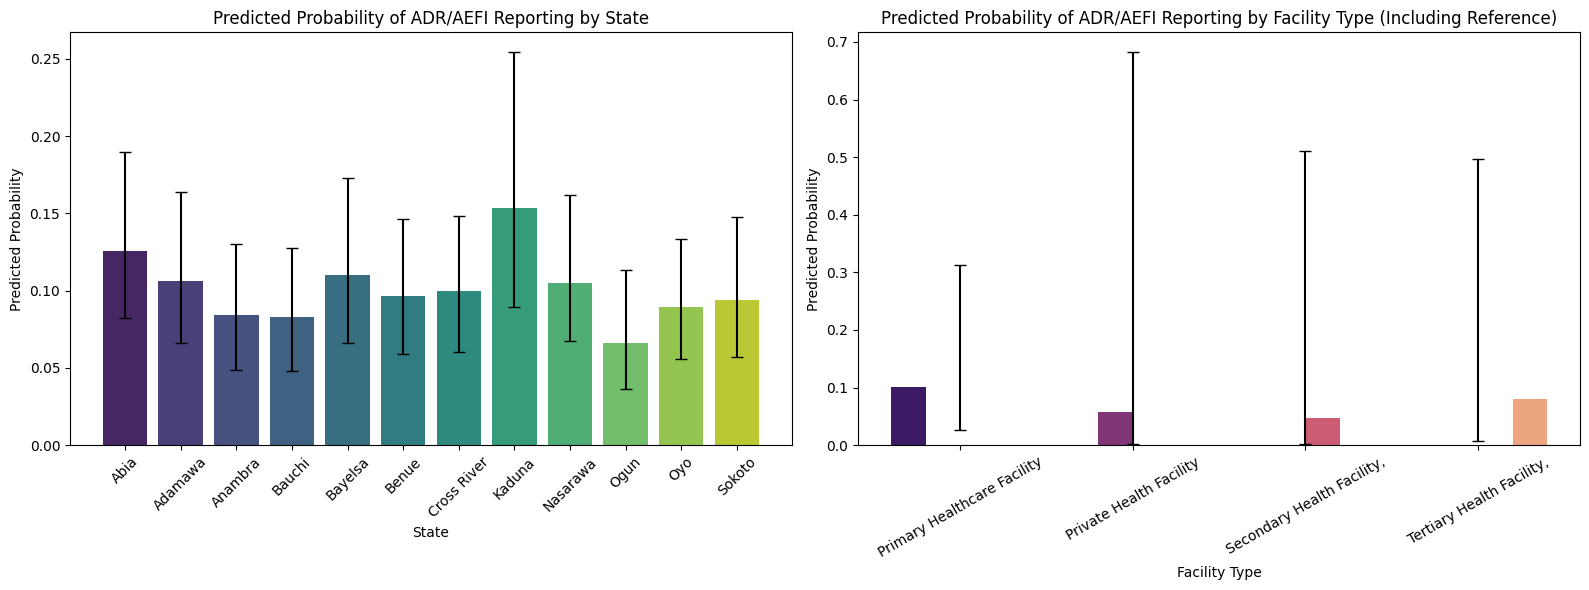

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import arviz as az # Import arviz for summary
import bambi as bmb # Import bambi to re-run the model
import pandas as pd # Import pandas for DataFrame operations
import re # Import re for regex operations

# --- Replicate df_model creation from cell qEY2MLhomxw- ---
# Clean column names
df.columns = df.columns.str.strip()

# Rename columns
df = df.rename(columns={
    'Q601. Have you submitted a suspected ADR/AEFI report before?': 'Reported',
    'Q606. What reasons are responsible for not reporting an ADR/AEFI from this facility to the National Pharmacovigilance Center in the last one year?': 'Q606',
    'Q207. Designation of Respondent': 'Designation',
    'Q301. Type of Health Facility of practice': 'FacilityType',
    'State': 'State',
    'Q203. Age of Respondent at last Birthday': 'Age',
    'Q204. Gender of respondent:': 'Gender',
    'Q206. Years of experience at present place of practice:': 'YearsExperience'
})

# Convert Age safely
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")

# Filter outliers from age column
df = df[(df["Age"] >= 20) & (df["Age"] <= 100)]

# Safe binary mapping (REPLACE, not MAP)
df["Reported"] = df["Reported"].replace({"Yes": 1, "No": 0})

# Standardize Designation column
designation_mapping = {
    'Community Health Extension Workers (CHEWs)': 'CHEW',
    'CHEWs': 'CHEW',
    'Community Health Extension Worker': 'CHEW',
    'Community Health Extension Workers': 'CHEW',
    'M&E officer': 'M&E Officer',
    'FACILITY M&E': 'M&E Officer',
    'Facility M&E': 'M&E Officer',
    'Head of M & E': 'M&E Officer',
    'Chief Pharmacy Technician ': 'Chief Pharmacy Technician',
    'Medical Lab Scientist': 'Lab. Scientist',
    'Medical laboratory scientist': 'Lab. Scientist',
    'Medical laboratory Scientist': 'Lab. Scientist',
    'Medical lab scientist': 'Lab. Scientist',
    'Nurse/Midwife': 'Nurse',
    'Mid wife': 'Nurse'
}
df['Designation'] = df['Designation'].astype(str).replace(designation_mapping)

# Barrier coding (these columns are not used in the bambi model below but are part of df's state after qEY2MLhomxw-)
df["Barrier_awareness"] = df["Q606"].str.contains("awareness", case=False).astype(int)
df["Barrier_ADR_AEFI_AEFI_info"] = df["Q606"].str.contains("information", case=False).astype(int)
df["Barrier_hospitalMgt"] = df["Q606"].str.contains("Hospital management", case=False).astype(int)
df["Barrier_training"] = df["Q606"].str.contains("Training", case=False).astype(int)
df["Barrier_complex"] = df["Q606"].str.contains("complex", case=False).astype(int)
df["Barrier_fear"] = df["Q606"].str.contains("fear", case=False).astype(int)
df["Barrier_feedback"] = df["Q606"].str.contains("feedback", case=False).astype(int)
df["Barrier_distance"] = df["Q606"].str.contains("too far", case=False).astype(int)
df["Barrier_time"] = df["Q606"].str.contains("time", case=False).astype(int)
df["Barrier_not_sure"] = df["Q606"].str.contains("not sure", case=False).astype(int)
df["Barrier_not_important"] = df["Q606"].str.contains("not serious", case=False).astype(int)
df["Barrier_NA"] = df["Q606"].str.contains("Not Applicable", case=False).astype(int)
df["Barrier_other"] = df["Q606"].str.contains("please specify", case=False).astype(int)

# Lock model data AFTER cleaning
cols_df_model = ["Reported", "Designation", "FacilityType",
        "Age", "Gender", "YearsExperience", "State"]

df_model = df[cols_df_model].dropna().copy()

# Enforce integer/binary on Reported column
df_model["Reported"] = df_model["Reported"].astype(int)

# Enforce categorical variables
for col_name in ["Designation", "FacilityType", "Gender", "State"]:
    df_model[col_name] = df_model[col_name].astype("category")
# --- End of df_model creation replication ---

# Re-run the bambi model to ensure 'result' holds the correct object for arviz.summary()
model = bmb.Model(
    "Reported ~ Designation + FacilityType + Age + Gender + YearsExperience + (1 + FacilityType | State)",
    df_model,
    family="bernoulli"
)
result = model.fit()

bambi_summary_df = az.summary(result)

# Extract fixed intercept mean from bambi model
intercept_mean = bambi_summary_df.loc['Intercept', 'mean']

# --- Prepare state_df for plotting with CIs from bambi model ---
# Create a temporary DataFrame from the summary that includes the index as a column
temp_state_df = bambi_summary_df[bambi_summary_df.index.str.startswith('1|State[')].reset_index().copy()
temp_state_df.rename(columns={'index': 'Full_Effect_Name', 'mean': 'State_effect', 'hdi_3%': 'Lower_CI_logit', 'hdi_97%': 'Upper_CI_logit'}, inplace=True)
# Extract 'State' from the 'Full_Effect_Name'
temp_state_df['State'] = temp_state_df['Full_Effect_Name'].str.extract(r'1\|State\[(.*?)\]')[0]
# Select and reorder columns for final state_plotting_df
state_plotting_df = temp_state_df[['State', 'State_effect', 'Lower_CI_logit', 'Upper_CI_logit']].copy()

# Calculate predicted probability and transform CI bounds from logit scale
state_plotting_df['Predicted_prob'] = 1 / (1 + np.exp(-(intercept_mean + state_plotting_df['State_effect'])))
state_plotting_df['Lower_CI'] = 1 / (1 + np.exp(-(intercept_mean + state_plotting_df['Lower_CI_logit'])))
state_plotting_df['Upper_CI'] = 1 / (1 + np.exp(-(intercept_mean + state_plotting_df['Upper_CI_logit'])))


# --- Prepare facility_df for plotting with CIs from bambi model (including reference category) ---

# Get unique states and facility types from df_model for a complete grid
all_states = df_model['State'].unique()
all_facility_types = df_model['FacilityType'].cat.categories # Use .categories for categorical dtype

# Determine the reference FacilityType for fixed and random effects (usually the first alphabetically)
reference_facility_type = df_model['FacilityType'].cat.categories[0]

# Initialize a list to store data for all FacilityType-State combinations
all_facility_state_data = []

for state_name in all_states:
    # Get the state's random intercept and its CI from state_plotting_df
    state_intercept_row = state_plotting_df[state_plotting_df['State'] == state_name].iloc[0]
    state_random_intercept = state_intercept_row['State_effect']
    lower_ci_intercept_state = state_intercept_row['Lower_CI_logit']
    upper_ci_intercept_state = state_intercept_row['Upper_CI_logit']

    for facility_type_name in all_facility_types:
        # Initialize effects for current FacilityType
        facility_type_fixed_effect = 0.0
        facility_type_fixed_effect_lower_ci = 0.0
        facility_type_fixed_effect_upper_ci = 0.0
        facility_type_random_slope = 0.0
        facility_type_random_slope_lower_ci = 0.0
        facility_type_random_slope_upper_ci = 0.0

        # If not the reference facility type, look up its specific fixed effect and random slope
        if facility_type_name != reference_facility_type:
            # Look up fixed effect for facility type
            fixed_effect_index_str = f'FacilityType[{facility_type_name}]'
            if fixed_effect_index_str in bambi_summary_df.index:
                fixed_effect_row = bambi_summary_df.loc[fixed_effect_index_str]
                facility_type_fixed_effect = fixed_effect_row['mean']
                facility_type_fixed_effect_lower_ci = fixed_effect_row['hdi_3%']
                facility_type_fixed_effect_upper_ci = fixed_effect_row['hdi_97%']

            # Look up random slope for facility type within this state
            random_slope_index_str = f'FacilityType|State[{facility_type_name}, {state_name}]'
            if random_slope_index_str in bambi_summary_df.index:
                random_slope_row = bambi_summary_df.loc[random_slope_index_str]
                facility_type_random_slope = random_slope_row['mean']
                facility_type_random_slope_lower_ci = random_slope_row['hdi_3%']
                facility_type_random_slope_upper_ci = random_slope_row['hdi_97%']

        # The total logit for a FacilityType in a State is the sum of:
        # fixed_intercept + fixed_effect_for_this_facility_type + state_random_intercept + facility_type_random_slope_for_this_state
        total_logit_effect = (
            intercept_mean +
            facility_type_fixed_effect +
            state_random_intercept +
            facility_type_random_slope
        )

        # Approximate CIs for the total logit effect (sum of individual CIs)
        # This is an approximation and might not perfectly align with true HDI for combined effects
        lower_bound_logit = (
            bambi_summary_df.loc['Intercept', 'hdi_3%'] +
            facility_type_fixed_effect_lower_ci +
            lower_ci_intercept_state +
            facility_type_random_slope_lower_ci
        )

        upper_bound_logit = (
            bambi_summary_df.loc['Intercept', 'hdi_97%'] +
            facility_type_fixed_effect_upper_ci +
            upper_ci_intercept_state +
            facility_type_random_slope_upper_ci
        )

        all_facility_state_data.append({
            'State': state_name,
            'FacilityType': facility_type_name,
            'Total_Logit_Effect': total_logit_effect,
            'Lower_Bound_Logit': lower_bound_logit,
            'Upper_Bound_Logit': upper_bound_logit
        })

facility_plotting_df = pd.DataFrame(all_facility_state_data)

# Calculate predicted probability and transform CI bounds from logit scale
# Corrected: Lower_Bound_Logit maps to Lower_CI, Upper_Bound_Logit maps to Upper_CI.
facility_plotting_df['Predicted_prob'] = 1 / (1 + np.exp(-facility_plotting_df['Total_Logit_Effect']))
facility_plotting_df['Lower_CI'] = 1 / (1 + np.exp(-facility_plotting_df['Lower_Bound_Logit']))
facility_plotting_df['Upper_CI'] = 1 / (1 + np.exp(-facility_plotting_df['Upper_Bound_Logit']))


# Aggregate to get the mean predicted probability and CIs for each FacilityType across all states
facility_grouped_plotting_df = facility_plotting_df.groupby('FacilityType').agg(
    Predicted_prob=('Predicted_prob', 'mean'),
    Lower_CI=('Lower_CI', 'mean'),
    Upper_CI=('Upper_CI', 'mean')
).reset_index()

# Ensure the FacilityType order for plotting is consistent with the model's categorical order
facility_grouped_plotting_df['FacilityType'] = pd.Categorical(
    facility_grouped_plotting_df['FacilityType'],
    categories=all_facility_types,
    ordered=True
)
facility_grouped_plotting_df = facility_grouped_plotting_df.sort_values('FacilityType')


# --- Visualize with Error Bars ---
fig, axes = plt.subplots(1, 2, figsize=(16,6))

# State-level chart with CI
sns.barplot(x="State", y="Predicted_prob", data=state_plotting_df, palette="viridis", ax=axes[0], hue="State", legend=False)
axes[0].errorbar(x=state_plotting_df["State"], y=state_plotting_df["Predicted_prob"],
                 yerr=[state_plotting_df["Predicted_prob"]-state_plotting_df["Lower_CI"],
                       state_plotting_df["Upper_CI"]-state_plotting_df["Predicted_prob"]],
                 fmt='none', c='black', capsize=4)
axes[0].set_title("Predicted Probability of ADR/AEFI Reporting by State")
axes[0].set_ylabel("Predicted Probability")
axes[0].set_xlabel("State")
axes[0].tick_params(axis='x', rotation=45)

# Facility-level chart with CI
sns.barplot(x="FacilityType", y="Predicted_prob", data=facility_grouped_plotting_df, palette="magma", ax=axes[1], hue="FacilityType", legend=False)
axes[1].errorbar(x=facility_grouped_plotting_df["FacilityType"], y=facility_grouped_plotting_df["Predicted_prob"],
                 yerr=[facility_grouped_plotting_df["Predicted_prob"]-facility_grouped_plotting_df["Lower_CI"],
                       facility_grouped_plotting_df["Upper_CI"]-facility_grouped_plotting_df["Predicted_prob"]],
                 fmt='none', c='black', capsize=4)
axes[1].set_title("Predicted Probability of ADR/AEFI Reporting by Facility Type (Including Reference)")
axes[1].set_ylabel("Predicted Probability")
axes[1].set_xlabel("Facility Type")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [ ]:

display(facility_grouped_plotting_df)
display(state_plotting_df)
# display(facility_df)

,FacilityType,Predicted_prob,Lower_CI,Upper_CI
0,Primary Healthcare Facility,0.101074,0.025806,0.312936
1,Private Health Facility,0.057868,0.001383,0.682592
2,"Secondary Health Facility,",0.046392,0.001741,0.510695
3,"Tertiary Health Facility,",0.080352,0.007186,0.496829


,State,State_effect,Lower_CI_logit,Upper_CI_logit,Predicted_prob,Lower_CI,Upper_CI
0,Abia,0.256,-0.215,0.745,0.125538,0.082262,0.189694
1,Adamawa,0.068,-0.454,0.567,0.106310,0.065927,0.163830
2,Anambra,-0.192,-0.770,0.298,0.084015,0.048939,0.130222
3,Bauchi,-0.205,-0.793,0.273,0.083020,0.047880,0.127416
4,Bayelsa,0.105,-0.451,0.630,0.109877,0.066112,0.172644
5,Benue,-0.037,-0.572,0.435,0.096739,0.059023,0.146540
6,Cross River,-0.006,-0.554,0.451,0.099481,0.060030,0.148552
7,Kaduna,0.490,-0.121,1.122,0.153553,0.089643,0.254453
8,Nasarawa,0.055,-0.428,0.553,0.105081,0.067547,0.161922
9,Ogun,-0.456,-1.085,0.143,0.065804,0.036194,0.113649


,State,State_Random_Intercept,FacilityType_Random_Slope,FacilityType,Predicted_prob
0,Abia,0.051332,-0.050354,Private Health Facility,0.668578
1,Adamawa,-0.043107,0.016892,Private Health Facility,0.662525
2,Anambra,-0.037769,-0.003123,Private Health Facility,0.659236
3,Bauchi,-0.028541,0.017039,Private Health Facility,0.665807
4,Bayelsa,0.024668,0.043889,Private Health Facility,0.683378
5,Benue,0.007357,0.005112,Private Health Facility,0.671119
6,Cross River,0.027032,-0.112838,Private Health Facility,0.649075
7,Kaduna,0.068961,-0.050712,Private Health Facility,0.672394
8,Nasarawa,0.070032,-0.051803,Private Health Facility,0.672389
9,Ogun,-0.116963,0.052009,Private Health Facility,0.653810


In [ ]:
# Extract variance components from bambi_summary_df
# Note: For logistic mixed models, the residual variance on the latent scale is often assumed to be pi^2/3.

# Variance of the random intercept for State
var_state = bambi_summary_df.loc['1|State_sigma', 'mean']**2

# Variance of the random slope for the first non-reference FacilityType (e.g., Private Health Facility)
# This attempts to mimic the result.cov_re.iloc[1,1] behavior for a specific random slope
var_facility = bambi_summary_df.loc['FacilityType|State_sigma[Private Health Facility]', 'mean']**2

# Residual variance for a logistic model on the latent (logit) scale
var_residual = np.pi**2 / 3 # Approximately 3.29

# Calculate ICCs
# ICC (State) - variance explained by State random intercepts relative to total variance
icc_state = var_state / (var_state + var_facility + var_residual)

# ICC (Facility) - variance explained by FacilityType random slopes relative to total variance
icc_facility = var_facility / (var_state + var_facility + var_residual)

print("ICC (State):", icc_state)
print("ICC (Facility):", icc_facility)

ICC (State): 0.029629959945651454
ICC (Facility): 0.29884903215345915


ICC (State): 0.029629959945651454
ICC (Facility): 0.29884903215345915
Proportion at Individual Level: 0.6715210079008893


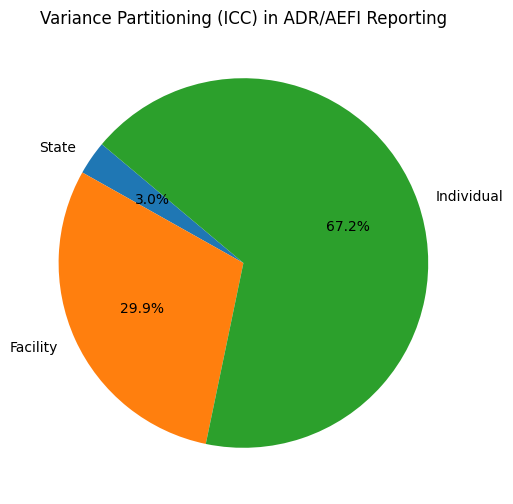

In [ ]:
# Extract variance components from bambi_summary_df
# Note: For logistic mixed models, the residual variance on the latent scale is often assumed to be pi^2/3.

# Variance of the random intercept for State
var_state = bambi_summary_df.loc['1|State_sigma', 'mean']**2

# Variance of the random slope for the first non-reference FacilityType (e.g., Private Health Facility)
# This attempts to mimic the result.cov_re.iloc[1,1] behavior for a specific random slope
var_facility = bambi_summary_df.loc['FacilityType|State_sigma[Private Health Facility]', 'mean']**2

# Residual variance for a logistic model on the latent (logit) scale
var_residual = np.pi**2 / 3 # Approximately 3.29

# ICC calculations
icc_state = var_state / (var_state + var_facility + var_residual)
icc_facility = var_facility / (var_state + var_facility + var_residual)
icc_residual = var_residual / (var_state + var_facility + var_residual)

print("ICC (State):", icc_state)
print("ICC (Facility):", icc_facility)
print("Proportion at Individual Level:", icc_residual)


# Pie Chart
import matplotlib.pyplot as plt

labels = ["State", "Facility", "Individual"]
sizes = [icc_state, icc_facility, icc_residual]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct="%1.1f%%", colors=colors, startangle=140)
plt.title("Variance Partitioning (ICC) in ADR/AEFI Reporting")
plt.show()




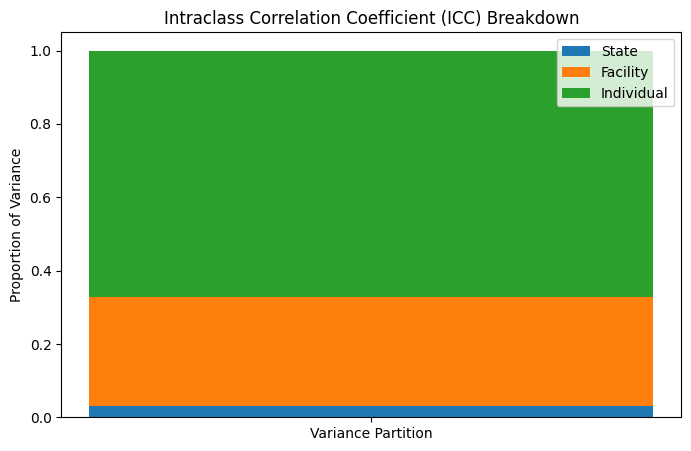

In [ ]:
# Stacked Bar Chart
plt.figure(figsize=(8,5))
plt.bar(["Variance Partition"], [icc_state], label="State", color="#1f77b4")
plt.bar(["Variance Partition"], [icc_facility], bottom=[icc_state], label="Facility", color="#ff7f0e")
plt.bar(["Variance Partition"], [icc_residual], bottom=[icc_state+icc_facility], label="Individual", color="#2ca02c")

plt.ylabel("Proportion of Variance")
plt.title("Intraclass Correlation Coefficient (ICC) Breakdown")
plt.legend()
plt.show()